# CSCI E 25: Computer Vision
# Graduate Project Proposal: Automated Detection and Localization of Plastic Printing Defects Using Computer Vision

## Ernest Ferdian

## Executive Summary:
In plastic packaging and printing industries, defects such as ink smearing, blurred lines, missing print regions, and surface inconsistencies can reduce product quality and brand value. These defects are often inspected manually, which can be slow, inconsistent, and difficult to scale. The goal of this project is to develop a computer vision pipeline to automatically identify defective images. Furthermore, this project where feasible and to some limited extent, will aim to locate the defects.

Because there is no widely used public dataset specifically labeled for plastic printing offset defects, this project will use an industrial manufacturing defect dataset as a proxy. The selected dataset is the Casting Product Image Data for Quality Inspection dataset from Kaggle. The primary focus of the project will be image classification using multiple trainable models within the scope of the course, including a baseline CNN and transfer learning approaches using ResNet and EfficientNet. In response to instructor feedback to explore object detection algorithm, the project will also explore a lightweight object detection extension on a small manually annotated subset in order to identify the approximate locations of defects.

The project first checked whether the dataset was suitable by examining the class distribution, image samples, image dimensions, pixel intensity histogram, CDF, and saturation levels. The histogram and CDF showed some illumination variation, which is common in industrial imaging. However, the amount of saturated bright and dark pixels was very small, so saturation was not a severe problem. Histogram equalization was still tested as a preprocessing step to improve contrast and reduce the effect of lighting variation.

Several models were compared: a raw baseline CNN, a histogram-equalized CNN, a histogram-equalized CNN with a lower learning rate, ResNet50 transfer learning, EfficientNetB0 transfer learning, and a small YOLO object detection extension. The raw CNN failed to detect defects, but histogram equalization greatly improved performance. The best defect-focused result came from the histogram-equalized CNN with lower learning rate, which achieved very high defect recall. This means it successfully caught most defective samples, although it also produced some false alarms.

ResNet50 provided the most balanced result because its defect precision and defect recall were closer together. In practical terms, ResNet50 missed more defects than the histogram-equalized CNN, but it made fewer false alarms. EfficientNetB0 did not perform well in this CPU-limited experiment because it almost never predicted the defect class. This may be due to the small reduced dataset, low image size, limited training time, and the difficulty of adapting ImageNet features to grayscale industrial images.

As an extension, a lightweight YOLO object detection experiment was also added to explore defect localization. Because the original dataset did not include bounding boxes, a small subset was manually labeled using Roboflow. The YOLO result was weak and should be treated only as a proof-of-concept. It showed that localizing defects requires more labeled images, better bounding boxes, and more training time.

Overall, the project shows that computer vision can be useful for industrial defect detection. The strongest practical model is the histogram-equalized CNN with lower learning rate if the goal is to catch as many defects as possible. ResNet50 is the better choice if the goal is a more balanced tradeoff between catching defects and reducing false alarms.

## Dataset Selection
**Dataset:** Casting Product Image Data for Quality Inspection  
**Kaggle link:** https://www.kaggle.com/datasets/ravirajsinh45/real-life-industrial-dataset-of-casting-product

This dataset contains grayscale images of industrial casting products labeled as defective or non-defective.

Although the dataset is not from plastic printing, it is suitable as a proxy because it contains surface defects such as irregular textures, holes, and distortions. These patterns are visually similar to printing defects such as blurred lines, ink smearing, and missing print regions.

### Dataset Suitability

- Approximately 7,000 labeled images  
- Binary classification (defective vs non-defective)  
- Clean and structured directory format  
- Manageable size for training on Macbook Air or Google Colab  

This dataset provides a strong foundation for building and evaluating a defect detection model.

## Initial Exploration

To verify dataset suitability, the following steps will be performed:

- Count number of images per class
- Visualize sample images
- Inspect image dimensions
- Check class balance

These steps ensure that the dataset is appropriate before model development begins.

In [5]:
from pathlib import Path
import os

DATA_DIR = Path("casting_data/casting_data")

DATA_DIR

PosixPath('casting_data/casting_data')

In [6]:
from collections import defaultdict

def count_images(data_dir):
    counts = defaultdict(dict)
    for split in ["train", "test"]:
        split_path = data_dir / split
        if split_path.exists():
            for cls in [p.name for p in split_path.iterdir() if p.is_dir()]:
                counts[split][cls] = len(list((split_path / cls).glob("*")))
    return counts

counts = count_images(DATA_DIR)
counts

defaultdict(dict,
            {'train': {'ok_front': 2875, 'def_front': 3758},
             'test': {'ok_front': 262, 'def_front': 453}})

In [7]:
from PIL import Image
import numpy as np

def inspect_image_dimensions(data_dir, num_samples=10):
    sizes = []
    
    for cls in os.listdir(data_dir / "train"):
        images = list((data_dir / "train" / cls).glob("*"))
        sample_images = images[:num_samples]
        
        for img_path in sample_images:
            img = Image.open(img_path)
            sizes.append(img.size)

    return sizes

sizes = inspect_image_dimensions(DATA_DIR)

print("Sample image sizes (width, height):")
print(sizes[:10])

sizes_np = np.array(sizes)

print("\nUnique sizes:")
print(np.unique(sizes_np, axis=0))

Sample image sizes (width, height):
[(300, 300), (300, 300), (300, 300), (300, 300), (300, 300), (300, 300), (300, 300), (300, 300), (300, 300), (300, 300)]

Unique sizes:
[[300 300]]


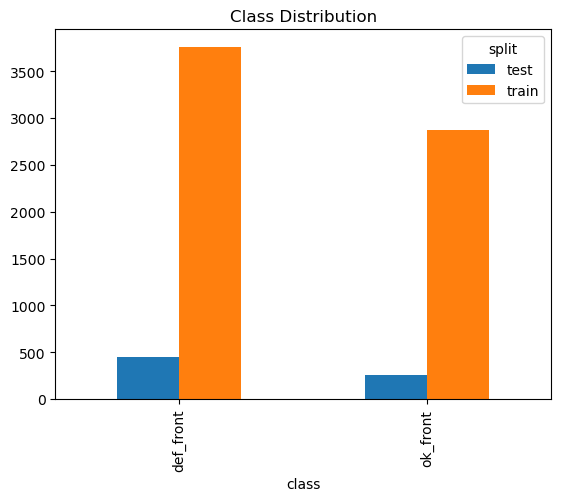

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

rows = []
for split, class_counts in counts.items():
    for cls, n in class_counts.items():
        rows.append({"split": split, "class": cls, "count": n})

df = pd.DataFrame(rows)

if not df.empty:
    df.pivot(index="class", columns="split", values="count").plot(kind="bar")
    plt.title("Class Distribution")
    plt.show()

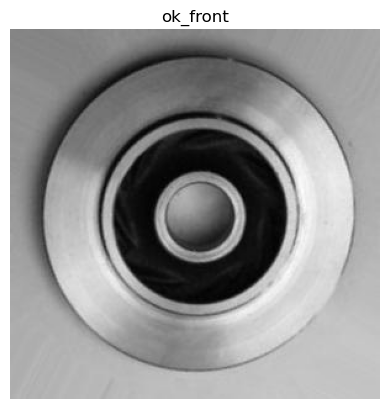

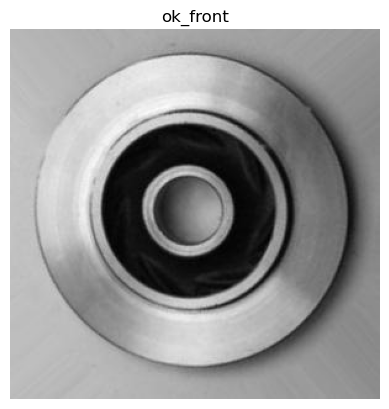

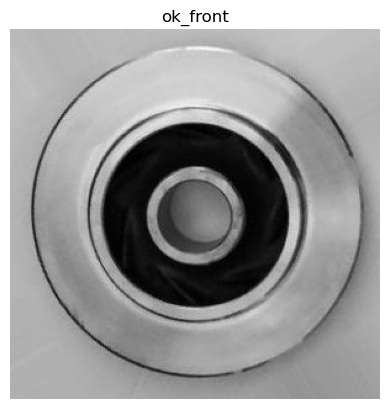

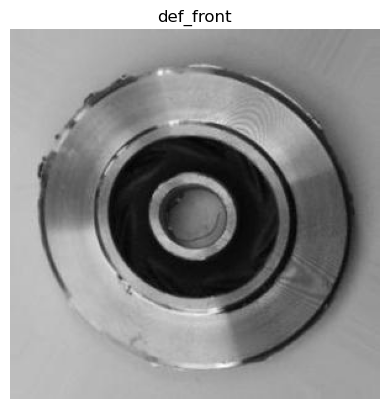

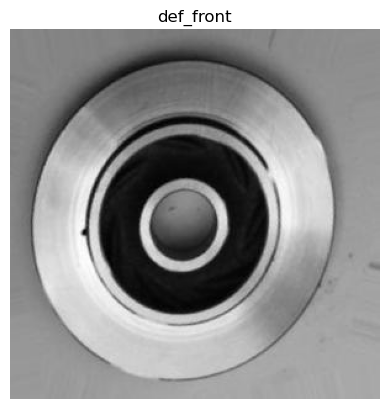

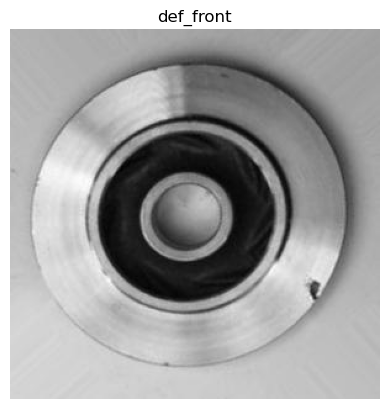

In [9]:
from PIL import Image
import random

def show_samples(data_dir):
    for cls in os.listdir(data_dir / "train"):
        images = list((data_dir / "train" / cls).glob("*"))
        sample = random.sample(images, 3)

        for img_path in sample:
            img = Image.open(img_path)
            plt.imshow(img, cmap="gray")
            plt.title(cls)
            plt.axis("off")
            plt.show()

show_samples(DATA_DIR)

## Preliminary Data Findings

Initial exploration indicates:

- Dataset is well structured and labeled  
- Defect patterns are visually distinguishable
- All images have consistent dimensions, which simplifies preprocessing and model input preparation
- The dataset exhibits a moderate class imbalance, with a slightly higher number of defective samples compared to non-defective samples. However, the imbalance is not severe and both classes are well represented in both the training and test sets.
- The class distribution is consistent across splits, which supports reliable model evaluation. 
- There is a possibility of illumination variation, which is common in industrial imaging.

## Proposed Models and Methods

### Model 1: Baseline CNN Raw
A simple CNN trained from scratch to establish baseline performance.

### Model 2: Baseline CNN Histogram Equalization
A simple CNN trained with Histogram Equalization to address illumination variation.

### Model 3: Baseline CNN Histogram Equalization with Lower Learning Rate
A simple CNN trained with Histogram Equalization to address illumination variation and lower learning rate to test different hyperparameter.

### Model 4: ResNet Transfer Learning
A pretrained ResNet model with frozen backbone and fine-tuning.

### Model 5: EfficientNetB0 Transfer Learning
A pretrained EfficientNet model for improved performance and efficiency.

### Extension - Model 6: Object Detection Extension (YOLO)
In addition to classification, this project will explore to some extent object detection to locate defect regions.
- A small subset of images will be manually annotated using Roboflow
- A lightweight YOLO model will be trained or fine-tuned
- This is an exploratory extension, given the limitation of CPU unit

## Libraries Preparation

In [13]:
import os
import random
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import shutil
from PIL import ImageOps

import cv2

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_recall_curve
)

from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model, Sequential
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.applications import ResNet50, EfficientNetB0
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.16.2


In [14]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Smaller image size catering to CPU
IMG_SIZE = 128
BATCH_SIZE = 16

FAST_MODE = True
TRAIN_PER_CLASS = 700
TEST_PER_CLASS = None

DATA_DIR = Path("casting_data/casting_data")

TRAIN_DIR = DATA_DIR / "train"
TEST_DIR = DATA_DIR / "test"

print("DATA_DIR:", DATA_DIR)
print("Train exists:", TRAIN_DIR.exists())
print("Test exists:", TEST_DIR.exists())

DATA_DIR: casting_data/casting_data
Train exists: True
Test exists: True


## Data Preparation

In [16]:
def count_images(data_dir):
    counts = defaultdict(dict)
    for split in ["train", "test"]:
        split_path = data_dir / split
        if split_path.exists():
            for cls_path in sorted([p for p in split_path.iterdir() if p.is_dir()]):
                counts[split][cls_path.name] = len(list(cls_path.glob("*")))
    return counts

counts = count_images(DATA_DIR)
counts

defaultdict(dict,
            {'train': {'def_front': 3758, 'ok_front': 2875},
             'test': {'def_front': 453, 'ok_front': 262}})

,split,class,count
0,train,def_front,3758
1,train,ok_front,2875
2,test,def_front,453
3,test,ok_front,262


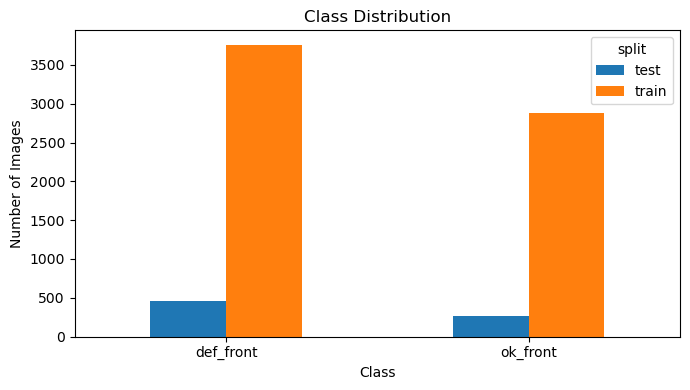

In [17]:
rows = []

for split, class_counts in counts.items():
    for cls, n in class_counts.items():
        rows.append({
            "split": split,
            "class": cls,
            "count": n
        })

df_counts = pd.DataFrame(rows)
display(df_counts)

pivot = df_counts.pivot(index="class", columns="split", values="count").fillna(0)

ax = pivot.plot(kind="bar", figsize=(7, 4))
plt.title("Class Distribution")
plt.ylabel("Number of Images")
plt.xlabel("Class")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [18]:
# Create smaller subset to cater limitation using CPU
WORK_DIR = Path("working_casting_data")

def make_subset(source_dir, target_dir, max_per_class=None, seed=42):
    random.seed(seed)
    target_dir.mkdir(parents=True, exist_ok=True)

    for cls_path in sorted([p for p in source_dir.iterdir() if p.is_dir()]):
        target_cls_dir = target_dir / cls_path.name
        target_cls_dir.mkdir(parents=True, exist_ok=True)

        image_paths = list(cls_path.glob("*"))
        random.shuffle(image_paths)

        if max_per_class is not None:
            image_paths = image_paths[:max_per_class]

        for img_path in image_paths:
            out_path = target_cls_dir / img_path.name
            if not out_path.exists():
                shutil.copy2(img_path, out_path)

# Fast mode to cater limitation using CPU
if FAST_MODE:
    train_subset_exists = (WORK_DIR / "train").exists()
    test_subset_exists = (WORK_DIR / "test").exists()

    if train_subset_exists and test_subset_exists:
        print("Complete working subset already exists:", WORK_DIR)
    else:
        print("Creating or repairing working subset...")
        make_subset(TRAIN_DIR, WORK_DIR / "train", max_per_class=TRAIN_PER_CLASS, seed=SEED)
        make_subset(TEST_DIR, WORK_DIR / "test", max_per_class=TEST_PER_CLASS, seed=SEED)

    TRAIN_USED = WORK_DIR / "train"
    TEST_USED = WORK_DIR / "test"
else:
    TRAIN_USED = TRAIN_DIR
    TEST_USED = TEST_DIR

print("Using train directory:", TRAIN_USED)
print("Using test directory:", TEST_USED)
print("Train exists:", TRAIN_USED.exists())
print("Test exists:", TEST_USED.exists())

print("\nTrain classes:", [p.name for p in TRAIN_USED.iterdir() if p.is_dir()])
print("Test classes:", [p.name for p in TEST_USED.iterdir() if p.is_dir()])

Complete working subset already exists: working_casting_data
Using train directory: working_casting_data/train
Using test directory: working_casting_data/test
Train exists: True
Test exists: True

Train classes: ['ok_front', 'def_front']
Test classes: ['ok_front', 'def_front']


In [19]:
working_counts = count_images(WORK_DIR if FAST_MODE else DATA_DIR)
working_counts

defaultdict(dict,
            {'train': {'def_front': 700, 'ok_front': 700},
             'test': {'def_front': 453, 'ok_front': 262}})

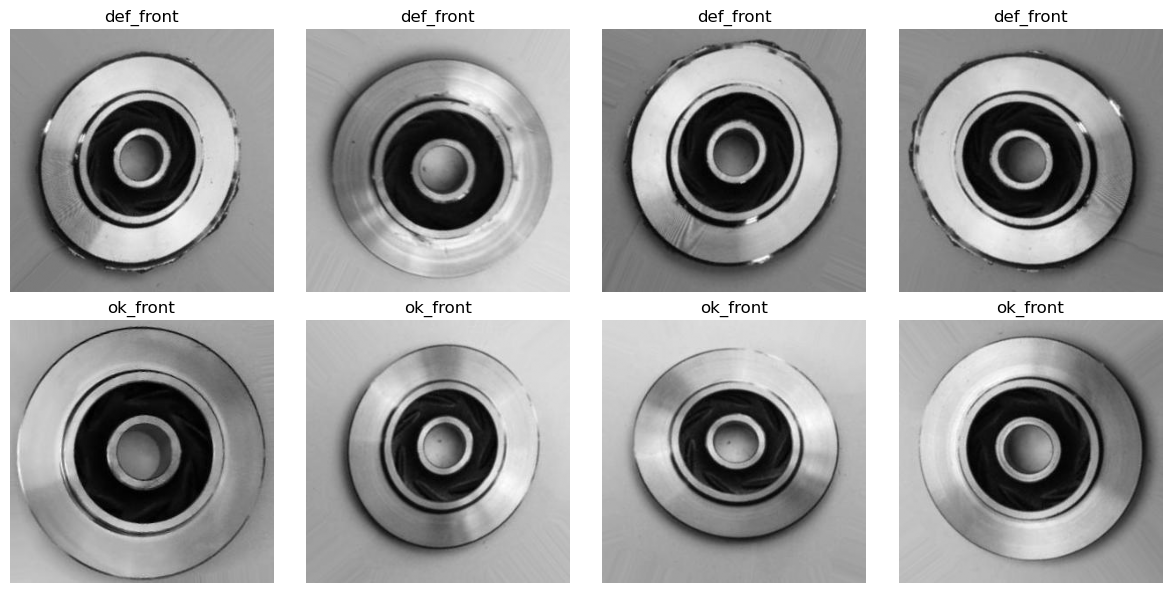

In [20]:
def show_sample_images(split_dir, samples_per_class=4):
    class_dirs = sorted([p for p in split_dir.iterdir() if p.is_dir()])
    fig, axes = plt.subplots(
        len(class_dirs),
        samples_per_class,
        figsize=(3 * samples_per_class, 3 * len(class_dirs))
    )

    if len(class_dirs) == 1:
        axes = np.expand_dims(axes, axis=0)

    for row, cls_dir in enumerate(class_dirs):
        image_paths = list(cls_dir.glob("*"))
        chosen = random.sample(image_paths, min(samples_per_class, len(image_paths)))

        for col in range(samples_per_class):
            ax = axes[row, col]
            ax.axis("off")

            if col < len(chosen):
                img = Image.open(chosen[col]).convert("L")
                ax.imshow(img, cmap="gray")
                ax.set_title(cls_dir.name)

    plt.tight_layout()
    plt.show()

show_sample_images(TRAIN_USED, samples_per_class=4)

In [21]:
def inspect_image_dimensions(split_dir, max_images_per_class=50):
    sizes = []

    for cls_dir in sorted([p for p in split_dir.iterdir() if p.is_dir()]):
        image_paths = list(cls_dir.glob("*"))[:max_images_per_class]

        for img_path in image_paths:
            with Image.open(img_path) as img:
                sizes.append(img.size)

    return np.array(sizes)

sizes = inspect_image_dimensions(TRAIN_USED)

print("First 10 image sizes:")
print(sizes[:10])

print("\nUnique image sizes:")
print(np.unique(sizes, axis=0))

First 10 image sizes:
[[300 300]
 [300 300]
 [300 300]
 [300 300]
 [300 300]
 [300 300]
 [300 300]
 [300 300]
 [300 300]
 [300 300]]

Unique image sizes:
[[300 300]]


### Checking Intensity Histogram and CDF for illumination variation

,low_saturation_pct,high_saturation_pct,mean_intensity,std_intensity
class,,,,
def_front,0.162104,0.027711,139.224237,58.587245
ok_front,0.231748,0.024170,149.334573,62.562891


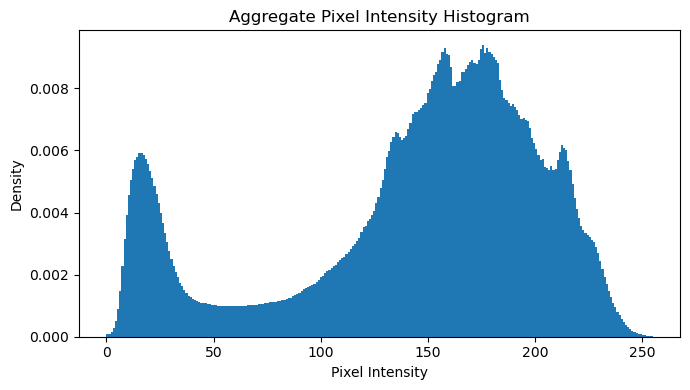

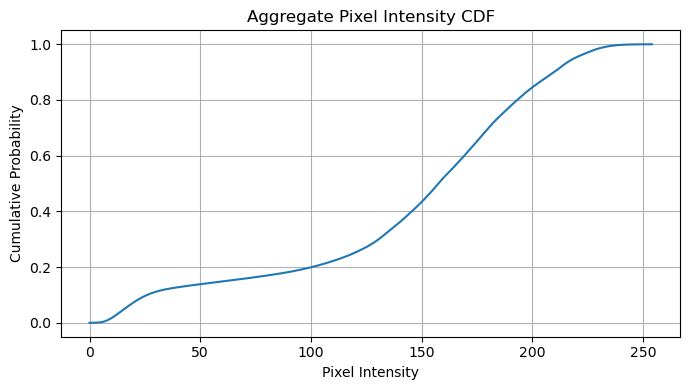

In [23]:
def collect_pixel_sample(split_dir, max_images_per_class=150):
    pixels = []
    saturation_rows = []

    for cls_dir in sorted([p for p in split_dir.iterdir() if p.is_dir()]):
        image_paths = list(cls_dir.glob("*"))[:max_images_per_class]

        for img_path in image_paths:
            img = Image.open(img_path).convert("L")
            arr = np.array(img)

            low_sat = np.mean(arr <= 5)
            high_sat = np.mean(arr >= 250)

            saturation_rows.append({
                "class": cls_dir.name,
                "file": img_path.name,
                "low_saturation_pct": low_sat * 100,
                "high_saturation_pct": high_sat * 100,
                "mean_intensity": arr.mean(),
                "std_intensity": arr.std()
            })

            pixels.append(arr.ravel())

    pixels = np.concatenate(pixels)
    sat_df = pd.DataFrame(saturation_rows)

    return pixels, sat_df

pixels, sat_df = collect_pixel_sample(TRAIN_USED, max_images_per_class=150)

display(sat_df.groupby("class")[[
    "low_saturation_pct",
    "high_saturation_pct",
    "mean_intensity",
    "std_intensity"
]].mean())

plt.figure(figsize=(7, 4))
plt.hist(pixels, bins=256, range=(0, 255), density=True)
plt.title("Aggregate Pixel Intensity Histogram")
plt.xlabel("Pixel Intensity")
plt.ylabel("Density")
plt.tight_layout()
plt.show()

hist, bin_edges = np.histogram(pixels, bins=256, range=(0, 255), density=True)
cdf = np.cumsum(hist)
cdf = cdf / cdf[-1]

plt.figure(figsize=(7, 4))
plt.plot(bin_edges[:-1], cdf)
plt.title("Aggregate Pixel Intensity CDF")
plt.xlabel("Pixel Intensity")
plt.ylabel("Cumulative Probability")
plt.grid(True)
plt.tight_layout()
plt.show()

###  COMMENT: The intensity histogram and CDF show that the dataset contains a broad range of pixel intensities, with most pixels concentrated in the mid-to-bright range. This suggests noticeable illumination variation, which is expected in industrial image settings. However, the percentage of saturated bright pixels is very low for both classes, approximately 0.02–0.03%, and the percentage of saturated dark pixels is also below 0.25%. Therefore, saturation does not appear to be a severe data quality problem. Even so, histogram equalization is included as an alternative preprocessing method to test whether contrast adjustment improves model performance.

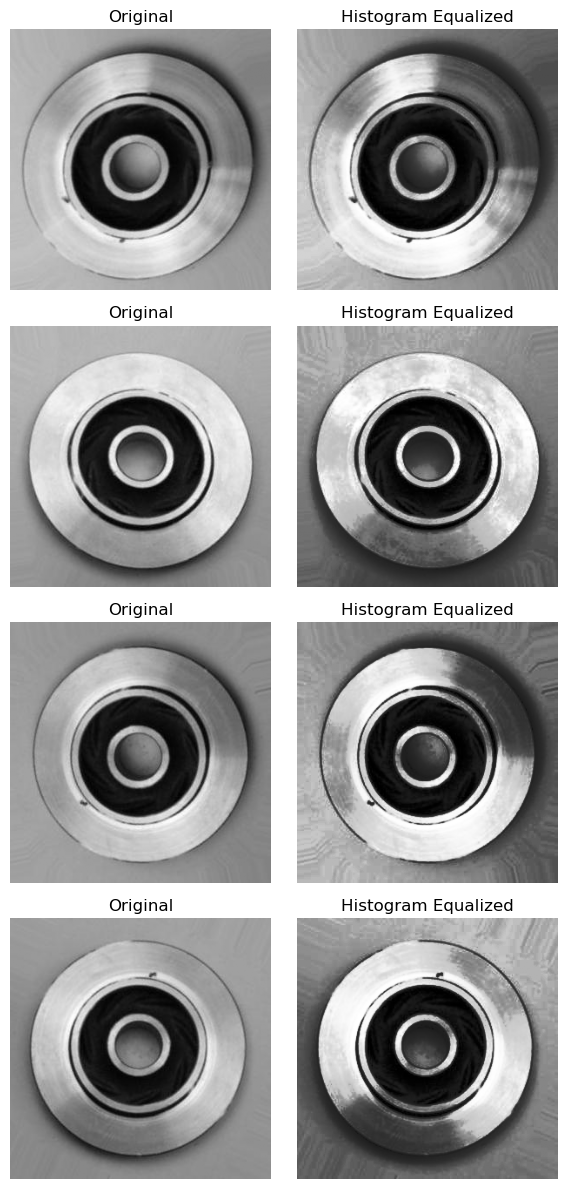

In [25]:
def show_histogram_adjustment_examples(split_dir, samples=4):
    image_paths = []

    for cls_dir in sorted([p for p in split_dir.iterdir() if p.is_dir()]):
        image_paths.extend(list(cls_dir.glob("*"))[:samples])

    chosen = random.sample(image_paths, min(samples, len(image_paths)))

    fig, axes = plt.subplots(len(chosen), 2, figsize=(6, 3 * len(chosen)))

    if len(chosen) == 1:
        axes = np.expand_dims(axes, axis=0)

    for i, img_path in enumerate(chosen):
        img = Image.open(img_path).convert("L")
        adjusted = ImageOps.equalize(img)

        axes[i, 0].imshow(img, cmap="gray")
        axes[i, 0].set_title("Original")
        axes[i, 0].axis("off")

        axes[i, 1].imshow(adjusted, cmap="gray")
        axes[i, 1].set_title("Histogram Equalized")
        axes[i, 1].axis("off")

    plt.tight_layout()
    plt.show()

show_histogram_adjustment_examples(TRAIN_USED, samples=4)

### Preprocessing

In [27]:
def identity_preprocess(x):
    # scale pixel values to [0, 1].
    return x / 255.0


def equalize_preprocess(x):
    # Histogram equalization preprocessing.
    x_uint8 = np.clip(x, 0, 255).astype("uint8")

    # Equalize channel by channel.
    channels = []
    for c in range(x_uint8.shape[-1]):
        channel_img = Image.fromarray(x_uint8[:, :, c])
        eq_channel = ImageOps.equalize(channel_img)
        channels.append(np.array(eq_channel))

    x_eq = np.stack(channels, axis=-1).astype("float32")

    return x_eq / 255.0

In [28]:
def make_generators(preprocess_fn, augment=True):
    if augment:
        train_datagen = ImageDataGenerator(
            preprocessing_function=preprocess_fn,
            validation_split=0.2,
            rotation_range=8,
            zoom_range=0.08,
            brightness_range=[0.85, 1.15],
            horizontal_flip=True
        )
    else:
        train_datagen = ImageDataGenerator(
            preprocessing_function=preprocess_fn,
            validation_split=0.2
        )

    test_datagen = ImageDataGenerator(
        preprocessing_function=preprocess_fn
    )

    train_gen = train_datagen.flow_from_directory(
        TRAIN_USED,
        target_size=(IMG_SIZE, IMG_SIZE),
        batch_size=BATCH_SIZE,
        class_mode="binary",
        subset="training",
        shuffle=True,
        seed=SEED,
        color_mode="rgb"
    )

    val_gen = train_datagen.flow_from_directory(
        TRAIN_USED,
        target_size=(IMG_SIZE, IMG_SIZE),
        batch_size=BATCH_SIZE,
        class_mode="binary",
        subset="validation",
        shuffle=False,
        seed=SEED,
        color_mode="rgb"
    )

    test_gen = test_datagen.flow_from_directory(
        TEST_USED,
        target_size=(IMG_SIZE, IMG_SIZE),
        batch_size=BATCH_SIZE,
        class_mode="binary",
        shuffle=False,
        color_mode="rgb"
    )

    return train_gen, val_gen, test_gen


train_raw, val_raw, test_raw = make_generators(identity_preprocess, augment=True)
train_eq, val_eq, test_eq = make_generators(equalize_preprocess, augment=True)

print("Class indices:", train_raw.class_indices)

Found 1120 images belonging to 2 classes.
Found 280 images belonging to 2 classes.
Found 715 images belonging to 2 classes.
Found 1120 images belonging to 2 classes.
Found 280 images belonging to 2 classes.
Found 715 images belonging to 2 classes.
Class indices: {'def_front': 0, 'ok_front': 1}


In [29]:
classes = train_raw.classes
class_weights_values = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(classes),
    y=classes
)

class_weights = {
    i: weight for i, weight in enumerate(class_weights_values)
}

class_weights

{0: 1.0, 1: 1.0}

## Training Model

In [31]:
def get_callbacks():
    return [
        EarlyStopping(
            monitor="val_loss",
            patience=3,
            restore_best_weights=True
        ),
        ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=2,
            min_lr=1e-6,
            verbose=1
        )
    ]

In [32]:
def plot_history(history, title):
    hist = history.history
    epochs = range(1, len(hist["loss"]) + 1)

    plt.figure(figsize=(6, 4))
    plt.plot(epochs, hist["loss"], label="Train Loss")
    plt.plot(epochs, hist["val_loss"], label="Validation Loss")
    plt.title(f"{title}: Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(6, 4))
    plt.plot(epochs, hist["accuracy"], label="Train Accuracy")
    plt.plot(epochs, hist["val_accuracy"], label="Validation Accuracy")
    plt.title(f"{title}: Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.tight_layout()
    plt.show()


def evaluate_model(model, test_gen, model_name):
    test_gen.reset()

    y_prob = model.predict(test_gen, verbose=0).ravel()
    y_pred = (y_prob >= 0.5).astype(int)
    y_true = test_gen.classes

    labels = list(test_gen.class_indices.keys())

    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)

    print(f"{model_name} Results")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1 Score : {f1:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=labels, zero_division=0))

    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    disp.plot()
    plt.title(f"{model_name}: Confusion Matrix")
    plt.tight_layout()
    plt.show()

    return {
        "model": model_name,
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1": f1
    }

### Model 1: Baseline CNN Raw

In [34]:
def build_baseline_cnn(input_shape=(128, 128, 3), learning_rate=1e-3):
    model = Sequential([
        layers.Input(shape=input_shape),

        layers.Conv2D(16, (3, 3), activation="relu", padding="same"),
        layers.MaxPooling2D(),

        layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
        layers.MaxPooling2D(),

        layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
        layers.MaxPooling2D(),

        layers.GlobalAveragePooling2D(),

        layers.Dense(64, activation="relu"),
        layers.Dropout(0.3),
        layers.Dense(1, activation="sigmoid")
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model


cnn_raw = build_baseline_cnn(input_shape=(IMG_SIZE, IMG_SIZE, 3), learning_rate=1e-3)
cnn_raw.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 27,809 (108.63 KB)

 Trainable params: 27,809 (108.63 KB)

 Non-trainable params: 0 (0.00 B)

In [35]:
history_cnn_raw = cnn_raw.fit(
    train_raw,
    validation_data=val_raw,
    epochs=8,
    callbacks=get_callbacks(),
    class_weight=class_weights,
    verbose=1
)

Epoch 1/8
70/70 ━━━━━━━━━━━━━━━━━━━━ 8s 97ms/step - accuracy: 0.5045 - loss: 0.6941 - val_accuracy: 0.5000 - val_loss: 0.6930 - learning_rate: 0.0010
Epoch 2/8
70/70 ━━━━━━━━━━━━━━━━━━━━ 8s 107ms/step - accuracy: 0.4964 - loss: 0.6935 - val_accuracy: 0.5000 - val_loss: 0.6931 - learning_rate: 0.0010
Epoch 3/8
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step - accuracy: 0.4996 - loss: 0.6932
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
70/70 ━━━━━━━━━━━━━━━━━━━━ 7s 106ms/step - accuracy: 0.5071 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6930 - learning_rate: 0.0010
Epoch 4/8
70/70 ━━━━━━━━━━━━━━━━━━━━ 8s 109ms/step - accuracy: 0.5000 - loss: 0.6930 - val_accuracy: 0.5000 - val_loss: 0.6928 - learning_rate: 5.0000e-04
Epoch 5/8
70/70 ━━━━━━━━━━━━━━━━━━━━ 8s 108ms/step - accuracy: 0.4991 - loss: 0.6932 - val_accuracy: 0.5857 - val_loss: 0.6927 - learning_rate: 5.0000e-04
Epoch 6/8
70/70 ━━━━━━━━━━━━━━━━━━━━ 8s 109ms/step - accuracy: 0.5339 - loss: 0.6926 - v

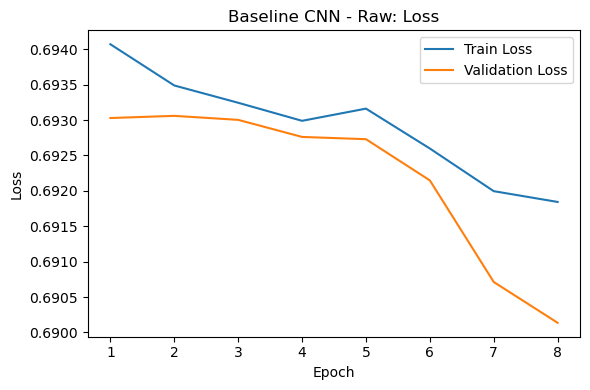

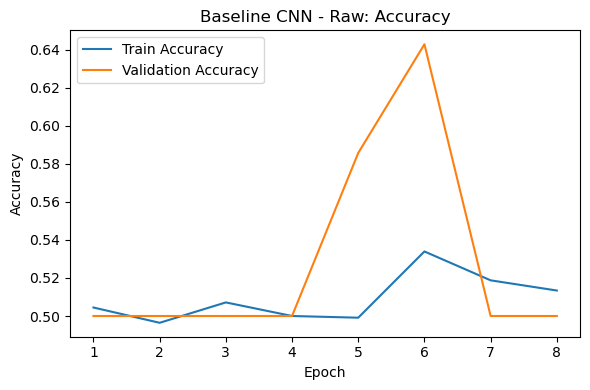

Baseline CNN - Raw Results
Accuracy : 0.3664
Precision: 0.3664
Recall   : 1.0000
F1 Score : 0.5363

Classification Report:
              precision    recall  f1-score   support

   def_front       0.00      0.00      0.00       453
    ok_front       0.37      1.00      0.54       262

    accuracy                           0.37       715
   macro avg       0.18      0.50      0.27       715
weighted avg       0.13      0.37      0.20       715



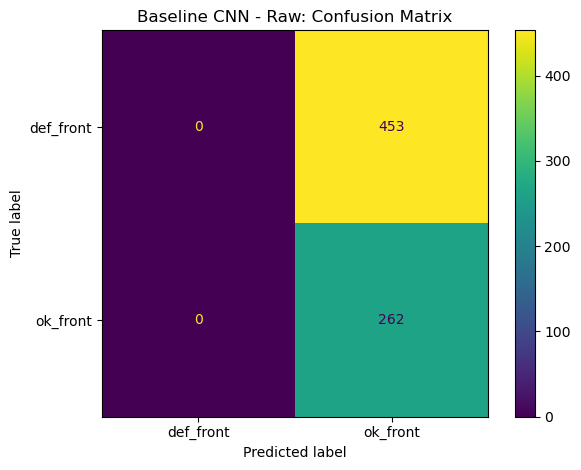

In [36]:
plot_history(history_cnn_raw, "Baseline CNN - Raw")
cnn_raw_results = evaluate_model(cnn_raw, test_raw, "Baseline CNN - Raw")

### COMMENT: The raw baseline CNN failed to detect defective samples, producing zero defective-class precision, recall, and F1 score. This indicates that the model did not learn useful defect-related visual features under the raw preprocessing condition.

### Model 2: Baseline CNN Histogram Equalization

In [39]:
cnn_eq = build_baseline_cnn(input_shape=(IMG_SIZE, IMG_SIZE, 3), learning_rate=1e-3)

history_cnn_eq = cnn_eq.fit(
    train_eq,
    validation_data=val_eq,
    epochs=8,
    callbacks=get_callbacks(),
    class_weight=class_weights,
    verbose=1
)

Epoch 1/8
70/70 ━━━━━━━━━━━━━━━━━━━━ 9s 118ms/step - accuracy: 0.4991 - loss: 0.6956 - val_accuracy: 0.5000 - val_loss: 0.6928 - learning_rate: 0.0010
Epoch 2/8
70/70 ━━━━━━━━━━━━━━━━━━━━ 8s 117ms/step - accuracy: 0.5170 - loss: 0.6939 - val_accuracy: 0.5000 - val_loss: 0.6923 - learning_rate: 0.0010
Epoch 3/8
70/70 ━━━━━━━━━━━━━━━━━━━━ 8s 117ms/step - accuracy: 0.5170 - loss: 0.6923 - val_accuracy: 0.5250 - val_loss: 0.6897 - learning_rate: 0.0010
Epoch 4/8
70/70 ━━━━━━━━━━━━━━━━━━━━ 9s 122ms/step - accuracy: 0.5643 - loss: 0.6896 - val_accuracy: 0.5107 - val_loss: 0.6898 - learning_rate: 0.0010
Epoch 5/8
70/70 ━━━━━━━━━━━━━━━━━━━━ 8s 121ms/step - accuracy: 0.5500 - loss: 0.6840 - val_accuracy: 0.5679 - val_loss: 0.6830 - learning_rate: 0.0010
Epoch 6/8
70/70 ━━━━━━━━━━━━━━━━━━━━ 8s 119ms/step - accuracy: 0.6170 - loss: 0.6654 - val_accuracy: 0.6321 - val_loss: 0.6563 - learning_rate: 0.0010
Epoch 7/8
70/70 ━━━━━━━━━━━━━━━━━━━━ 8s 118ms/step - accuracy: 0.6277 - loss: 0.6582 - val_acc

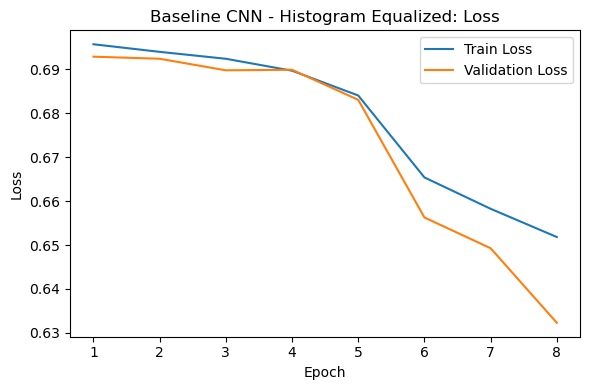

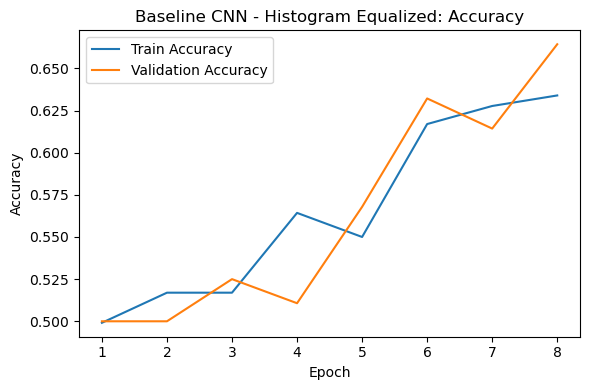

Baseline CNN - Histogram Equalized Results
Accuracy : 0.6685
Precision: 0.6263
Recall   : 0.2366
F1 Score : 0.3435

Classification Report:
              precision    recall  f1-score   support

   def_front       0.68      0.92      0.78       453
    ok_front       0.63      0.24      0.34       262

    accuracy                           0.67       715
   macro avg       0.65      0.58      0.56       715
weighted avg       0.66      0.67      0.62       715



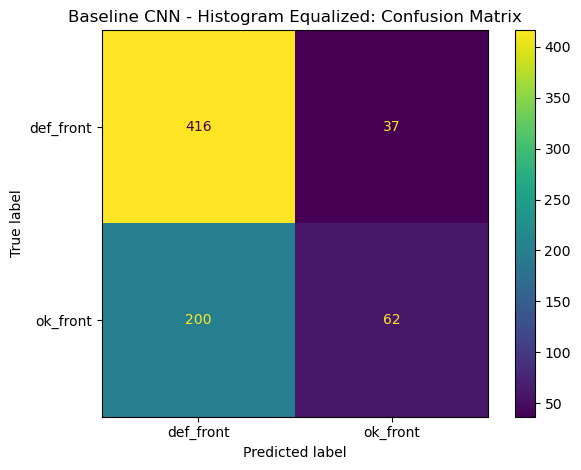

In [40]:
plot_history(history_cnn_eq, "Baseline CNN - Histogram Equalized")
cnn_eq_results = evaluate_model(cnn_eq, test_eq, "Baseline CNN - Histogram Equalized")

### COMMENT: The first baseline model exposed a data preparation problem. After analyzing the intensity histogram and CDF, histogram equalization was tested as a preprocessing correction. This improved defect detection substantially, especially defective-class recall.

### Model 3: Baseline CNN Histogram Equalization with Lower Learning Rate to test different hyperparameter

In [43]:
cnn_eq_lwrlr = build_baseline_cnn(input_shape=(IMG_SIZE, IMG_SIZE, 3), learning_rate=5e-4)

history_cnn_eq_lwrlr = cnn_eq_lwrlr.fit(
    train_eq,
    validation_data=val_eq,
    epochs=8,
    callbacks=get_callbacks(),
    class_weight=class_weights,
    verbose=1
)

Epoch 1/8
70/70 ━━━━━━━━━━━━━━━━━━━━ 9s 121ms/step - accuracy: 0.4768 - loss: 0.6949 - val_accuracy: 0.5000 - val_loss: 0.6923 - learning_rate: 5.0000e-04
Epoch 2/8
70/70 ━━━━━━━━━━━━━━━━━━━━ 8s 114ms/step - accuracy: 0.5107 - loss: 0.6922 - val_accuracy: 0.6286 - val_loss: 0.6913 - learning_rate: 5.0000e-04
Epoch 3/8
70/70 ━━━━━━━━━━━━━━━━━━━━ 9s 123ms/step - accuracy: 0.5446 - loss: 0.6892 - val_accuracy: 0.6643 - val_loss: 0.6874 - learning_rate: 5.0000e-04
Epoch 4/8
70/70 ━━━━━━━━━━━━━━━━━━━━ 8s 117ms/step - accuracy: 0.5446 - loss: 0.6841 - val_accuracy: 0.5857 - val_loss: 0.6772 - learning_rate: 5.0000e-04
Epoch 5/8
70/70 ━━━━━━━━━━━━━━━━━━━━ 9s 123ms/step - accuracy: 0.6045 - loss: 0.6729 - val_accuracy: 0.6393 - val_loss: 0.6586 - learning_rate: 5.0000e-04
Epoch 6/8
70/70 ━━━━━━━━━━━━━━━━━━━━ 8s 115ms/step - accuracy: 0.6250 - loss: 0.6495 - val_accuracy: 0.6714 - val_loss: 0.6323 - learning_rate: 5.0000e-04
Epoch 7/8
70/70 ━━━━━━━━━━━━━━━━━━━━ 8s 120ms/step - accuracy: 0.6259 

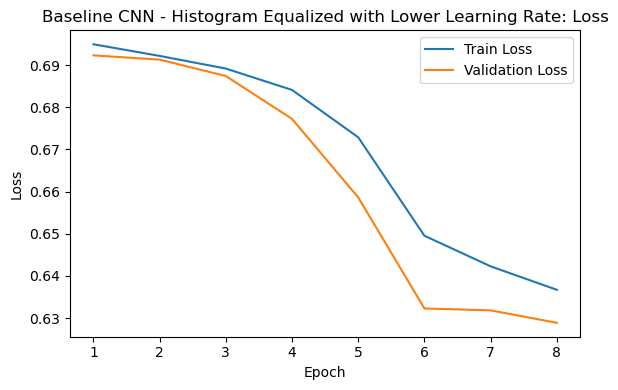

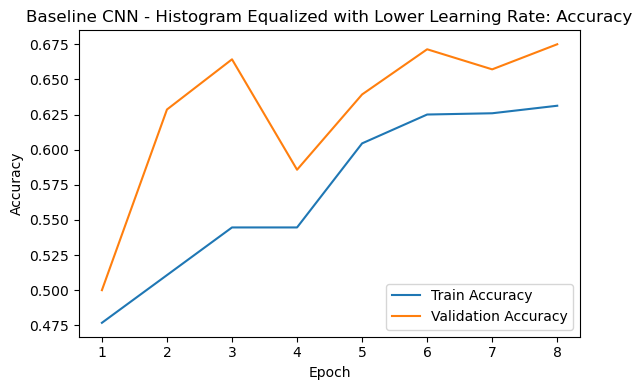

Baseline CNN - Histogram Equalized with Lower Learning Rate Results
Accuracy : 0.6783
Precision: 0.7500
Recall   : 0.1832
F1 Score : 0.2945

Classification Report:
              precision    recall  f1-score   support

   def_front       0.67      0.96      0.79       453
    ok_front       0.75      0.18      0.29       262

    accuracy                           0.68       715
   macro avg       0.71      0.57      0.54       715
weighted avg       0.70      0.68      0.61       715



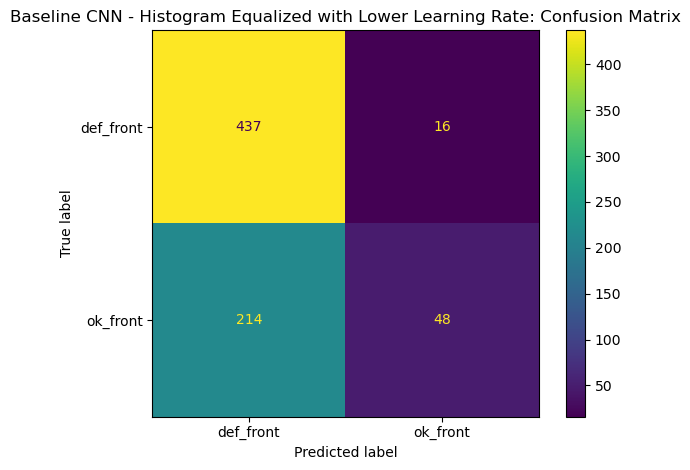

In [44]:
plot_history(history_cnn_eq_lwrlr, "Baseline CNN - Histogram Equalized with Lower Learning Rate")
cnn_eq_lwrlr_results = evaluate_model(cnn_eq_lwrlr, test_eq, "Baseline CNN - Histogram Equalized with Lower Learning Rate")

### COMMENT: The lower-learning-rate histogram-equalized CNN improved the defect-focused metrics, suggesting that smaller weight updates helped training become more stable. This model achieved the highest accuracy in identifying defects.

### Model 4: ResNet50 Model

In [47]:
def build_resnet_model(input_shape=(128, 128, 3), learning_rate=1e-4):
    base = ResNet50(
        weights="imagenet",
        include_top=False,
        input_shape=input_shape
    )

    base.trainable = False

    inputs = keras.Input(shape=input_shape)
    x = base(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(1, activation="sigmoid")(x)

    model = Model(inputs, outputs)

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model


resnet_model = build_resnet_model(input_shape=(IMG_SIZE, IMG_SIZE, 3), learning_rate=1e-4)
resnet_model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 4, 4, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │         2,049 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,589,761 (89.99 MB)

 Trainable params: 2,049 (8.00 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [48]:
history_resnet = resnet_model.fit(
    train_eq,
    validation_data=val_eq,
    epochs=6,
    callbacks=get_callbacks(),
    class_weight=class_weights,
    verbose=1
)

Epoch 1/6
70/70 ━━━━━━━━━━━━━━━━━━━━ 37s 477ms/step - accuracy: 0.4857 - loss: 0.7606 - val_accuracy: 0.5000 - val_loss: 0.7103 - learning_rate: 1.0000e-04
Epoch 2/6
70/70 ━━━━━━━━━━━━━━━━━━━━ 35s 501ms/step - accuracy: 0.4955 - loss: 0.7262 - val_accuracy: 0.4929 - val_loss: 0.6974 - learning_rate: 1.0000e-04
Epoch 3/6
70/70 ━━━━━━━━━━━━━━━━━━━━ 35s 501ms/step - accuracy: 0.4955 - loss: 0.7168 - val_accuracy: 0.5071 - val_loss: 0.6935 - learning_rate: 1.0000e-04
Epoch 4/6
70/70 ━━━━━━━━━━━━━━━━━━━━ 35s 497ms/step - accuracy: 0.4946 - loss: 0.7096 - val_accuracy: 0.5107 - val_loss: 0.6897 - learning_rate: 1.0000e-04
Epoch 5/6
70/70 ━━━━━━━━━━━━━━━━━━━━ 35s 498ms/step - accuracy: 0.5071 - loss: 0.7002 - val_accuracy: 0.6357 - val_loss: 0.6863 - learning_rate: 1.0000e-04
Epoch 6/6
70/70 ━━━━━━━━━━━━━━━━━━━━ 35s 502ms/step - accuracy: 0.5250 - loss: 0.6999 - val_accuracy: 0.6214 - val_loss: 0.6818 - learning_rate: 1.0000e-04


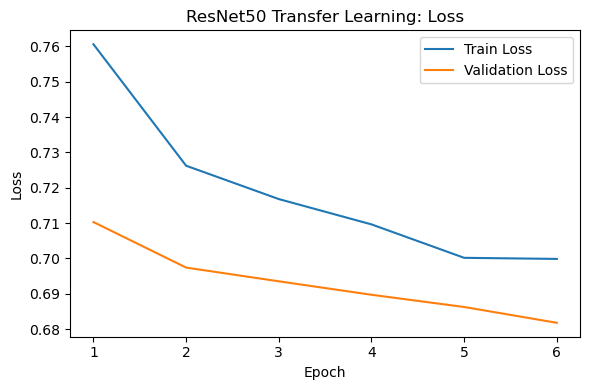

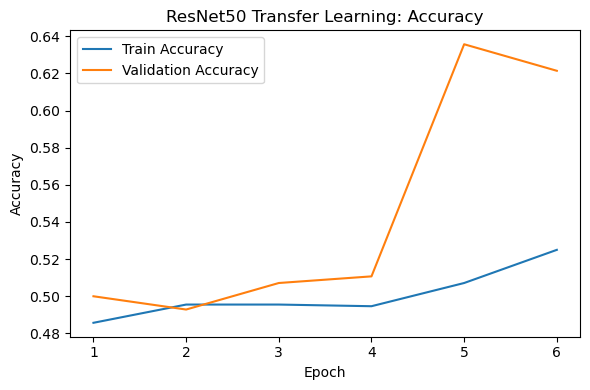

ResNet50 Transfer Learning Results
Accuracy : 0.6322
Precision: 0.4987
Recall   : 0.7519
F1 Score : 0.5997

Classification Report:
              precision    recall  f1-score   support

   def_front       0.80      0.56      0.66       453
    ok_front       0.50      0.75      0.60       262

    accuracy                           0.63       715
   macro avg       0.65      0.66      0.63       715
weighted avg       0.69      0.63      0.64       715



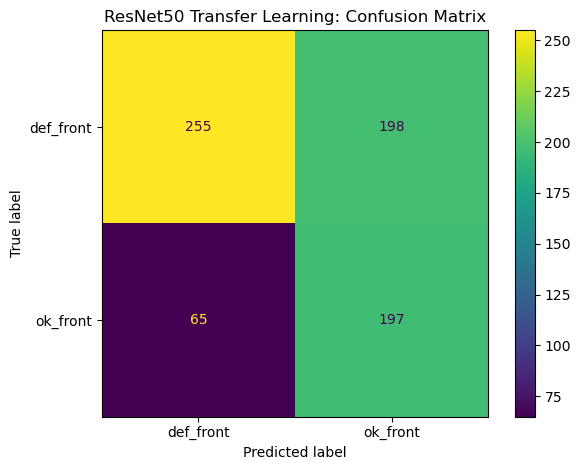

In [49]:
plot_history(history_resnet, "ResNet50 Transfer Learning")
resnet_results = evaluate_model(resnet_model, test_eq, "ResNet50 Transfer Learning")

### COMMENT: ResNet50 has slightly higher accuracy than the histogram-equalized CNN and better defect precision. Its recall score is closer to its precision score. Thus, while histogram-equalized CNN catches more defects, but ResNet50 makes fewer false alarms. Less false alarm is also valuable in industry setup. Thus, ResNet50 is more balanced overall compared to histogram-equalized CNN.

### Model 5: EfficientNetB0 Model

In [52]:
def build_efficientnet_model(input_shape=(128, 128, 3), learning_rate=1e-4):
    base = EfficientNetB0(
        weights="imagenet",
        include_top=False,
        input_shape=input_shape
    )

    base.trainable = False

    inputs = keras.Input(shape=input_shape)
    x = base(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(1, activation="sigmoid")(x)

    model = Model(inputs, outputs)

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model


effnet_model = build_efficientnet_model(input_shape=(IMG_SIZE, IMG_SIZE, 3), learning_rate=1e-4)
effnet_model.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 4, 4, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_4      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,050,852 (15.45 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [53]:
history_effnet = effnet_model.fit(
    train_eq,
    validation_data=val_eq,
    epochs=6,
    callbacks=get_callbacks(),
    class_weight=class_weights,
    verbose=1
)

Epoch 1/6
70/70 ━━━━━━━━━━━━━━━━━━━━ 16s 152ms/step - accuracy: 0.4973 - loss: 0.7003 - val_accuracy: 0.5000 - val_loss: 0.6933 - learning_rate: 1.0000e-04
Epoch 2/6
70/70 ━━━━━━━━━━━━━━━━━━━━ 13s 189ms/step - accuracy: 0.5000 - loss: 0.7013 - val_accuracy: 0.5000 - val_loss: 0.6933 - learning_rate: 1.0000e-04
Epoch 3/6
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step - accuracy: 0.5080 - loss: 0.7015
Epoch 3: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
70/70 ━━━━━━━━━━━━━━━━━━━━ 13s 187ms/step - accuracy: 0.4929 - loss: 0.7044 - val_accuracy: 0.5000 - val_loss: 0.6933 - learning_rate: 1.0000e-04
Epoch 4/6
70/70 ━━━━━━━━━━━━━━━━━━━━ 13s 185ms/step - accuracy: 0.4723 - loss: 0.7041 - val_accuracy: 0.5000 - val_loss: 0.6933 - learning_rate: 5.0000e-05
Epoch 5/6
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step - accuracy: 0.4872 - loss: 0.7012
Epoch 5: ReduceLROnPlateau reducing learning rate to 2.499999936844688e-05.
70/70 ━━━━━━━━━━━━━━━━━━━━ 13s 187ms/step - accuracy: 0.4982 - l

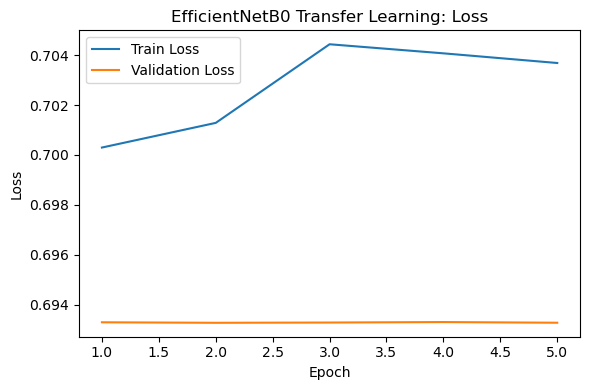

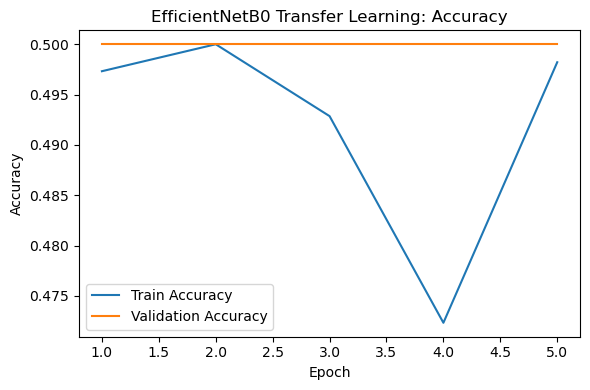

EfficientNetB0 Transfer Learning Results
Accuracy : 0.6336
Precision: 0.0000
Recall   : 0.0000
F1 Score : 0.0000

Classification Report:
              precision    recall  f1-score   support

   def_front       0.63      1.00      0.78       453
    ok_front       0.00      0.00      0.00       262

    accuracy                           0.63       715
   macro avg       0.32      0.50      0.39       715
weighted avg       0.40      0.63      0.49       715



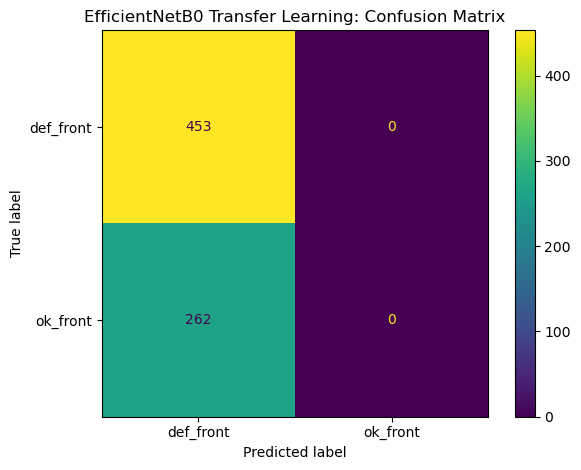

In [54]:
plot_history(history_effnet, "EfficientNetB0 Transfer Learning")
effnet_results = evaluate_model(effnet_model, test_eq, "EfficientNetB0 Transfer Learning")

### COMMENT: For EfficientNetB0, the validation loss is almost flat around 0.693 across all epochs. That is important because 0.693 is close to random guessing for binary classification. The validation loss suggests that EfficientNetB0 did not meaningfully learn a useful validation pattern in this setup with its current constraints.

## Model Comparison

,model,accuracy,precision,recall,f1
0,Baseline CNN - Raw,0.366434,0.366434,1.000000,0.536336
1,Baseline CNN - Histogram Equalized,0.668531,0.626263,0.236641,0.343490
2,Baseline CNN - Histogram Equalized with Lower ...,0.678322,0.750000,0.183206,0.294479
3,ResNet50 Transfer Learning,0.632168,0.498734,0.751908,0.599696
4,EfficientNetB0 Transfer Learning,0.633566,0.000000,0.000000,0.000000


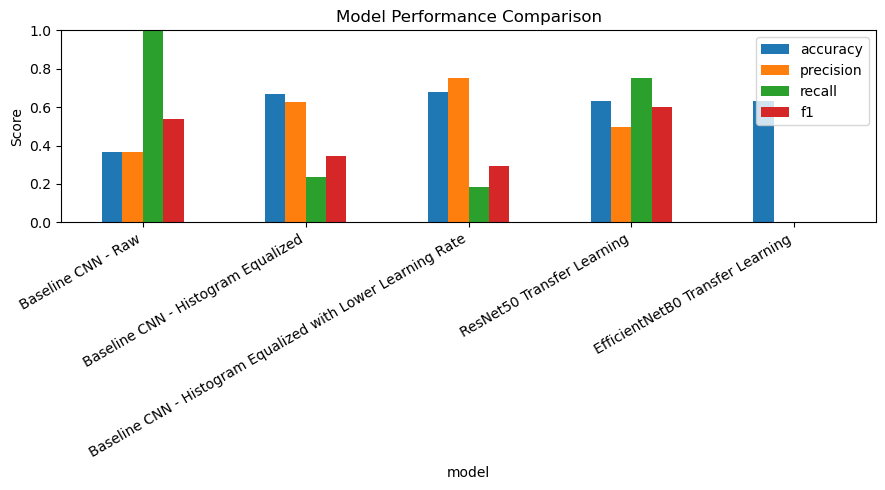

In [57]:
results_df = pd.DataFrame([
    cnn_raw_results,
    cnn_eq_results,
    cnn_eq_lwrlr_results,
    resnet_results,
    effnet_results
])

display(results_df)

results_df.set_index("model")[["accuracy", "precision", "recall", "f1"]].plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

### We want to see from the angle of detecting defects. As such, we are converting the metrics to defect focused metric.

,model,accuracy,defect_precision,defect_recall,defect_f1
0,Baseline CNN - Raw,0.366434,0.000000,0.000000,0.000000
1,Baseline CNN - Histogram Equalized,0.668531,0.675325,0.918322,0.778297
2,Baseline CNN - Histogram Equalized with Lower ...,0.678322,0.671275,0.964680,0.791667
3,ResNet50 Transfer Learning,0.632168,0.796875,0.562914,0.659767
4,EfficientNetB0 Transfer Learning,0.633566,0.633566,1.000000,0.775685


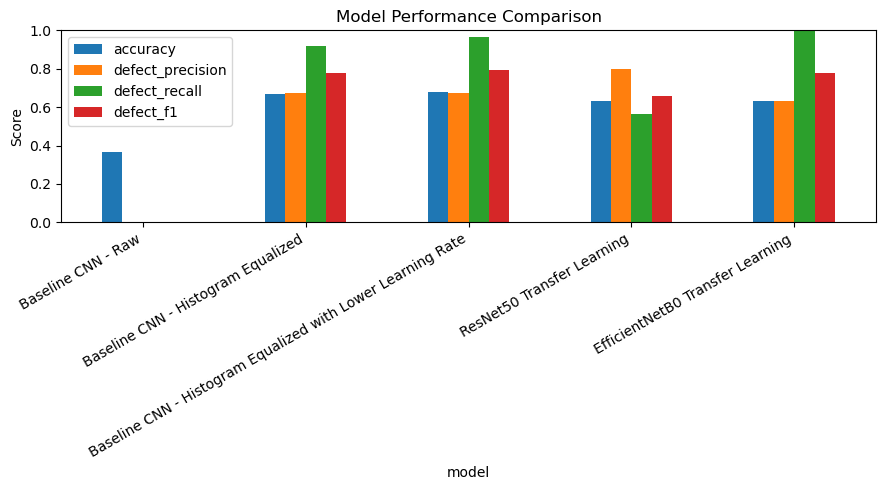

In [59]:
# Convert to defect focused metric
def evaluate_defect_focused_model(model, test_gen, model_name, threshold=0.5):
    test_gen.reset()

    y_prob = model.predict(test_gen, verbose=0).ravel()
    y_pred = (y_prob >= threshold).astype(int)
    y_true = test_gen.classes

    defect_label = test_gen.class_indices["def_front"]

    acc = accuracy_score(y_true, y_pred)
    defect_precision = precision_score(y_true, y_pred, pos_label=defect_label, zero_division=0)
    defect_recall = recall_score(y_true, y_pred, pos_label=defect_label, zero_division=0)
    defect_f1 = f1_score(y_true, y_pred, pos_label=defect_label, zero_division=0)

    return {
        "model": model_name,
        "accuracy": acc,
        "defect_precision": defect_precision,
        "defect_recall": defect_recall,
        "defect_f1": defect_f1
    }

defect_results_df = pd.DataFrame([
    evaluate_defect_focused_model(cnn_raw, test_raw, "Baseline CNN - Raw"),
    evaluate_defect_focused_model(cnn_eq, test_eq, "Baseline CNN - Histogram Equalized"),
    evaluate_defect_focused_model(cnn_eq_lwrlr, test_eq, "Baseline CNN - Histogram Equalized with Lower Learning Rate"),
    evaluate_defect_focused_model(resnet_model, test_eq, "ResNet50 Transfer Learning"),
    evaluate_defect_focused_model(effnet_model, test_eq, "EfficientNetB0 Transfer Learning")
])

display(defect_results_df)

defect_results_df.set_index("model")[["accuracy", "defect_precision", "defect_recall", "defect_f1"]].plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

## Conclusion
### Baseline CNN - Raw: The raw baseline CNN failed to detect defective samples, producing zero defective-class precision, recall, and F1 score. This indicates that the model did not learn useful defect-related visual features under the raw preprocessing condition.
### Baseline CNN - Histogram Equalized: There is a strong and meaningful improvement. The model successfully detected about 90% of defective images.However, precision is lower than recall. This means the model catches most defects, but it also incorrectly flags some good products as defective. For industrial inspection, this tradeoff is often acceptable at an early stage because missing defects is usually worse than over-flagging good samples.
### Baseline CNN - Histogram Equalized with Lower Learning Rate: Lower learning rate shows improvement compared to higher learning rate. Due to CPU restriction, I am unable tp do wide coverage research. This is to show, for future work, this model can be further improved by testing alternative hyperparameter values.
### ResNet 50: ResNet50 has slightly higher accuracy than the histogram-equalized CNN and better defect precision. Its recall score is closer to its precision score. Thus, while histogram-equalized CNN catches more defects, but ResNet50 makes fewer false alarms. It shows that ResNet50 is more balanced overall compared to histogram-equalized CNN.
### EfficientNetB0: The model almost never predicts def_front. When it does predict defect, it is correct, so precision becomes 1.00. But because it detects only about 3% of defects, recall is terrible. Thus, this is not a useful defect detector. Few possible reasons that may cause this are because we are using CPU friendly reduced dataset, small image size, or EfficientNet may not adapt well to greyscale industrial image.
### Overall, the histogram-equalized CNN is best if the priority is maximizing defect detection, while ResNet50 is the better balanced model because it is making fewer false alarms.

## Project Extension: Object Detection YOLO + Roboflow

In [62]:
DETECTION_DIR = Path("detection_subset")
DETECTION_IMAGES_DIR = DETECTION_DIR / "images"

DETECTION_IMAGES_DIR.mkdir(parents=True, exist_ok=True)

defective_dir = TRAIN_USED / "def_front"
defective_images = list(defective_dir.glob("*"))

subset_size = 40
selected_images = random.sample(defective_images, min(subset_size, len(defective_images)))

for img_path in selected_images:
    out_path = DETECTION_IMAGES_DIR / img_path.name
    if not out_path.exists():
        shutil.copy2(img_path, out_path)

print(f"Copied {len(selected_images)} images to {DETECTION_IMAGES_DIR}")

Copied 40 images to detection_subset/images


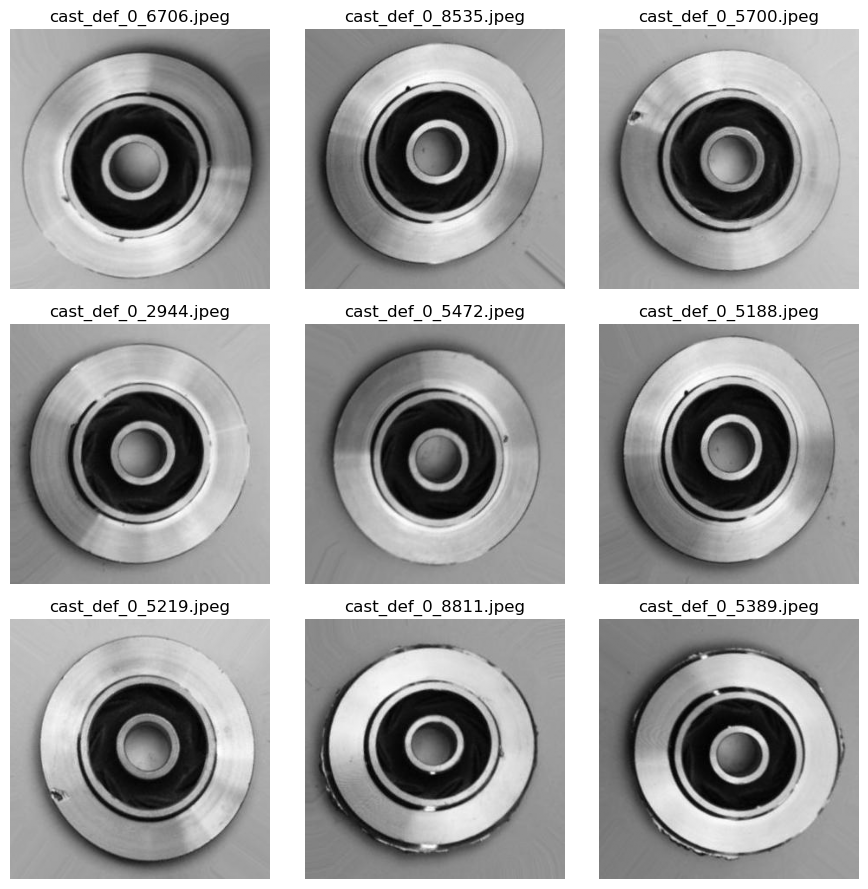

In [63]:
subset_files = list(DETECTION_IMAGES_DIR.glob("*"))[:9]

plt.figure(figsize=(9, 9))

for i, img_path in enumerate(subset_files):
    img = Image.open(img_path).convert("L")
    plt.subplot(3, 3, i + 1)
    plt.imshow(img, cmap="gray")
    plt.title(img_path.name)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [64]:
best_model = resnet_model

best_model.save("best_plastic_printing_defect_classifier.keras")

print("Saved best model.")

Saved best model.


In [65]:
# YOLO labeling folder
DETECTION_DIR = Path("detection_yolo")
IMG_TRAIN_DIR = DETECTION_DIR / "images_train"
IMG_VAL_DIR = DETECTION_DIR / "images_val"

IMG_TRAIN_DIR.mkdir(parents=True, exist_ok=True)
IMG_VAL_DIR.mkdir(parents=True, exist_ok=True)

# Use defective images only
defective_dir = TRAIN_USED / "def_front"
defective_images = list(defective_dir.glob("*"))

random.seed(42)
selected_images = random.sample(defective_images, 50)

train_images = selected_images[:40]
val_images = selected_images[40:]

for img_path in train_images:
    shutil.copy2(img_path, IMG_TRAIN_DIR / img_path.name)

for img_path in val_images:
    shutil.copy2(img_path, IMG_VAL_DIR / img_path.name)

print("Created YOLO labeling subset.")
print("Train images:", len(list(IMG_TRAIN_DIR.glob('*'))))
print("Validation images:", len(list(IMG_VAL_DIR.glob('*'))))

Created YOLO labeling subset.
Train images: 40
Validation images: 10


In [66]:
zip_path = shutil.make_archive("detection_yolo_upload", "zip", DETECTION_DIR)

print("Zip file created:", zip_path)

Zip file created: /Users/ernest/detection_yolo_upload.zip


In [67]:
YOLO_DATA_DIR = Path("Plastic-Printing-Defect-Localization-1").resolve()
YOLO_YAML = YOLO_DATA_DIR / "data_fixed.yaml"

yaml_text = f"""
path: {YOLO_DATA_DIR}
train: train/images
val: valid/images

nc: 1
names:
  0: defect
"""

YOLO_YAML.write_text(yaml_text)

print("Fixed YAML saved to:", YOLO_YAML)
print(YOLO_YAML.read_text())

Fixed YAML saved to: /Users/ernest/Plastic-Printing-Defect-Localization-1/data_fixed.yaml

path: /Users/ernest/Plastic-Printing-Defect-Localization-1
train: train/images
val: valid/images

nc: 1
names:
  0: defect



In [68]:
from ultralytics import YOLO

yolo_model = YOLO("yolov8n.pt")

yolo_results = yolo_model.train(
    data=str(YOLO_YAML),
    epochs=5,
    imgsz=128,
    batch=4,
    device="cpu",
    workers=0,
    project="yolo_runs",
    name="defect_yolo_cpu",
    exist_ok=True
)

New https://pypi.org/project/ultralytics/8.4.51 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.48 🚀 Python-3.11.14 torch-2.11.0 CPU (Apple M2)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/Users/ernest/Plastic-Printing-Defect-Localization-1/data_fixed.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=5, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=128, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_s

In [69]:
pt_files = list(Path(".").rglob("best.pt"))

for p in pt_files:
    print(p)

runs/detect/yolo_runs/defect_yolo_cpu/weights/best.pt


In [70]:
trained_model_path = Path("runs/detect/yolo_runs/defect_yolo_cpu/weights/best.pt")

print("Trained YOLO model exists:", trained_model_path.exists())

yolo_model = YOLO(str(trained_model_path))

val_img_dir = YOLO_DATA_DIR / "valid" / "images"
sample_images = list(val_img_dir.glob("*"))[:5]

print("Number of validation images used for prediction:", len(sample_images))
print(sample_images[:5])

pred_results = yolo_model.predict(
    source=[str(p) for p in sample_images],
    imgsz=128,
    conf=0.01,
    device="cpu",
    save=True,
    project="yolo_defect_predictions",
    name="trained_defect_examples_conf001",
    exist_ok=True
)

print("Trained YOLO prediction complete.")

Trained YOLO model exists: True
Number of validation images used for prediction: 5
[PosixPath('/Users/ernest/Plastic-Printing-Defect-Localization-1/valid/images/cast_def_0_1286_jpeg.rf.da6e223e9a22cf44adfa6139c16357a7.jpg'), PosixPath('/Users/ernest/Plastic-Printing-Defect-Localization-1/valid/images/cast_def_0_9996_jpeg.rf.01041de06808753bdb576aa4e5a299eb.jpg'), PosixPath('/Users/ernest/Plastic-Printing-Defect-Localization-1/valid/images/cast_def_0_4948_jpeg.rf.f75210830862b975bdbd505cb088b5f6.jpg'), PosixPath('/Users/ernest/Plastic-Printing-Defect-Localization-1/valid/images/cast_def_0_8950_jpeg.rf.2990b40a68fe3112171330a717d953b9.jpg'), PosixPath('/Users/ernest/Plastic-Printing-Defect-Localization-1/valid/images/cast_def_0_8358_jpeg.rf.ae1892d0a8452644d9281da244c8af2b.jpg')]

0: 128x128 4 defects, 4.9ms
1: 128x128 8 defects, 4.9ms
2: 128x128 4 defects, 4.9ms
3: 128x128 5 defects, 4.9ms
4: 128x128 4 defects, 4.9ms
Speed: 0.2ms preprocess, 4.9ms inference, 0.3ms postprocess per image 

Prediction images found: 5


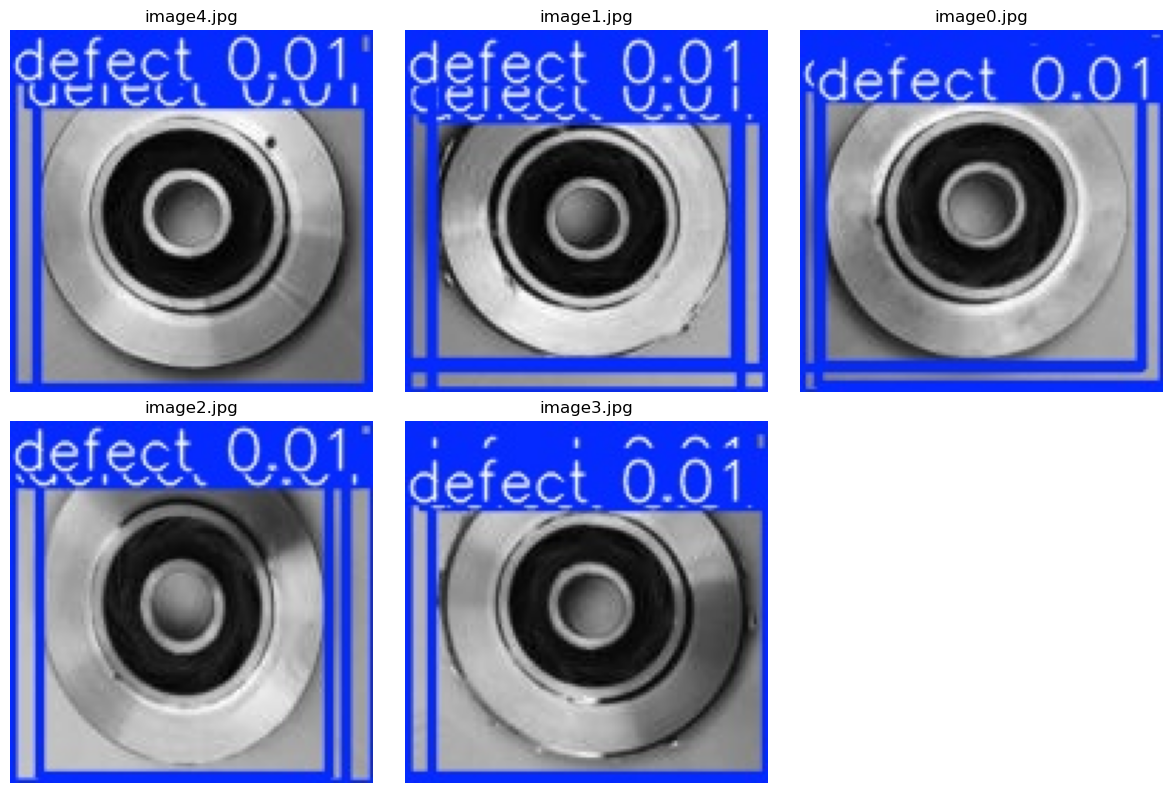

In [71]:
pred_dir = Path("/Users/ernest/runs/detect/yolo_defect_predictions/trained_defect_examples_conf001")

pred_imgs = []
for ext in ["*.jpg", "*.jpeg", "*.png", "*.bmp"]:
    pred_imgs.extend(list(pred_dir.glob(ext)))

print("Prediction images found:", len(pred_imgs))

if len(pred_imgs) > 0:
    plt.figure(figsize=(12, 8))
    for i, img_path in enumerate(pred_imgs[:6]):
        img = Image.open(img_path)
        plt.subplot(2, 3, i + 1)
        plt.imshow(img)
        plt.title(img_path.name)
        plt.axis("off")
    plt.tight_layout()
    plt.show()

## Future Work & Improvement

### The YOLO object detection extension was able to produce defect-class predictions on validation images, but the confidence scores were very low and the predicted boxes covered most of the image rather than tightly localizing the defect regions. This indicates that the small manually labeled subset was insufficient for reliable object detection. The result suggests that defect localization requires more annotated images, tighter bounding boxes, higher input resolution, and longer training. Therefore, YOLO is treated as a proof-of-concept extension rather than a main goal in this project.